## Prepare the data

### 1. Load the fine-tuning data

In [1]:
import json
import tiktoken

In [2]:
file_path = "../output/fine_tuning.json"
with open(file_path, "r") as file:
    data = json.load(file)

data

['<|startoftext|>You<|separator|>🐨<|endoftext|>',
 '<|startoftext|>Assistant<|separator|>Hey<|endoftext|>',
 '<|startoftext|>You<|separator|>You like stickers?<|endoftext|>',
 '<|startoftext|>Assistant<|separator|>Yea I do<|endoftext|>',
 '<|startoftext|>You<|separator|>Like these 😂<|endoftext|>',
 '<|startoftext|>Assistant<|separator|>Awww<|endoftext|>',
 '<|startoftext|>You<|separator|>Wanna see me now? Coming for break?<|endoftext|>',
 '<|startoftext|>Assistant<|separator|>When will you leave?<|endoftext|>',
 '<|startoftext|>You<|separator|>8<|endoftext|>',
 '<|startoftext|>Assistant<|separator|>I was in bala just noe<|endoftext|>',
 '<|startoftext|>You<|separator|>Back to work now?<|endoftext|>',
 "<|startoftext|>Assistant<|separator|>I have no work today\nYea come to my team\nIt's chill<|endoftext|>",
 '<|startoftext|>You<|separator|>My team too\nOkay tell when to meet<|endoftext|>',
 '<|startoftext|>Assistant<|separator|>You are free now?<|endoftext|>',
 '<|startoftext|>You<|sepa

### 2. Load the tokenizer

In [3]:
gpt2_whatsapp = tiktoken.get_encoding("gpt2")
max_vocab_id = gpt2_whatsapp.n_vocab

tokenizer = tiktoken.Encoding(
    name="gpt2_whatsapp",
    pat_str=gpt2_whatsapp._pat_str,
    mergeable_ranks=gpt2_whatsapp._mergeable_ranks,
    special_tokens={
        **gpt2_whatsapp._special_tokens,
        **{
            "<|startoftext|>": max_vocab_id,
            "<|separator|>": max_vocab_id + 1,
            "<|unk|>": max_vocab_id + 2,
            "<|padding|>": max_vocab_id + 3
        }
    }
)

tokenizer.n_vocab

50261

In [4]:
gpt2_whatsapp.n_vocab, tokenizer.n_vocab

(50257, 50261)

### 3. Tokenize the sequences

In [5]:
tokenized_data = []
for item in data:
    tokenized_item = tokenizer.encode(item, allowed_special="all")
    tokenized_data.append(tokenized_item)

len(tokenized_data[0])

7

### 4. Split the data

We need to be careful when splitting the data. We want to keep the multi-turn conversations complete in each part. So, the training and validation sets should start with a `You` message and end with an `Assistant` message.

In [6]:
initial_split_index = int(0.95 * len(data))

# Adjusting the index to ensure that the training set ends with "Assistant" message
# and that the validation set starts with "You" message

# Scanning backward to find an Assistant message
split_index = initial_split_index
while split_index > 0 and not data[split_index-1].startswith('<|startoftext|>Assistant'):
    split_index -= 1

train_data = data[:split_index]
val_data = data[split_index:]

print("Training set: ")
print(f"Start message: {train_data[0].split('<|separator|>')[0]}")
print(f"End message: {train_data[-1].split('<|separator|>')[0]}")

print("\nValidation set: ")
print(f"Start message: {val_data[0].split('<|separator|>')[0]}")
print(f"End message: {val_data[-1].split('<|separator|>')[0]}")

Training set: 
Start message: <|startoftext|>You
End message: <|startoftext|>Assistant

Validation set: 
Start message: <|startoftext|>You
End message: <|startoftext|>Assistant


In [7]:
train_data[:10]

['<|startoftext|>You<|separator|>🐨<|endoftext|>',
 '<|startoftext|>Assistant<|separator|>Hey<|endoftext|>',
 '<|startoftext|>You<|separator|>You like stickers?<|endoftext|>',
 '<|startoftext|>Assistant<|separator|>Yea I do<|endoftext|>',
 '<|startoftext|>You<|separator|>Like these 😂<|endoftext|>',
 '<|startoftext|>Assistant<|separator|>Awww<|endoftext|>',
 '<|startoftext|>You<|separator|>Wanna see me now? Coming for break?<|endoftext|>',
 '<|startoftext|>Assistant<|separator|>When will you leave?<|endoftext|>',
 '<|startoftext|>You<|separator|>8<|endoftext|>',
 '<|startoftext|>Assistant<|separator|>I was in bala just noe<|endoftext|>']

In [8]:
val_data[:10]

['<|startoftext|>You<|separator|>Hm when you will sleep?<|endoftext|>',
 '<|startoftext|>Assistant<|separator|>I have to sleep early\nTomorrow at 3 I have to wake up<|endoftext|>',
 '<|startoftext|>You<|separator|>Hm yes\nYou must be tried now\nCleaning done<|endoftext|>',
 '<|startoftext|>Assistant<|separator|>Only one floor\nTomorrow next floor<|endoftext|>',
 '<|startoftext|>You<|separator|>Aha 🫤, hope you are okay now?<|endoftext|>',
 "<|startoftext|>Assistant<|separator|>Yea I am\nI love cleaning\nI don't like sitting simply<|endoftext|>",
 '<|startoftext|>You<|separator|>Ya home cleaning 😌\nGood then,\nTake care moon<|endoftext|>',
 '<|startoftext|>Assistant<|separator|>I do\nYou had food?<|endoftext|>',
 '<|startoftext|>You<|separator|>Yepi 😌, I will munch chips later<|endoftext|>',
 '<|startoftext|>Assistant<|separator|>Did you reach?<|endoftext|>']

We got the index that we should use to split the data. Now, let's split the tokenized data.

In [9]:
train_data = tokenized_data[:split_index]
val_data = tokenized_data[split_index:]

Now, we need to combine the `You` and `Assistant` turns into one sequence. We will make sure that the resulting sequence does not exceed the `block_size`.

In [10]:
block_size = 256


def combine_turns(data: list[list[int]], should_trim_long_sequences: bool) -> list[list[int]]:
    combined_turns_data = []
    for i in range(0, len(data)-1, 2):
        you_message = data[i]
        assistant_message = data[i+1]
        if not you_message or not assistant_message:
            continue

        final_message = you_message + assistant_message
        if len(final_message) > block_size and should_trim_long_sequences:
            final_message = final_message[-block_size:]
            print(tokenizer.decode(final_message))

        combined_turns_data.append(final_message)
    return combined_turns_data


combined_train_data = combine_turns(
    data=train_data,
    should_trim_long_sequences=True
)
combined_val_data = combine_turns(
    data=val_data,
    should_trim_long_sequences=True
)

In [11]:
tokenizer.decode_batch(combined_train_data)[:3]

['<|startoftext|>You<|separator|>🐨<|endoftext|><|startoftext|>Assistant<|separator|>Hey<|endoftext|>',
 '<|startoftext|>You<|separator|>You like stickers?<|endoftext|><|startoftext|>Assistant<|separator|>Yea I do<|endoftext|>',
 '<|startoftext|>You<|separator|>Like these 😂<|endoftext|><|startoftext|>Assistant<|separator|>Awww<|endoftext|>']

In [12]:
tokenizer.decode_batch(combined_val_data)[:3]

['<|startoftext|>You<|separator|>Hm when you will sleep?<|endoftext|><|startoftext|>Assistant<|separator|>I have to sleep early\nTomorrow at 3 I have to wake up<|endoftext|>',
 '<|startoftext|>You<|separator|>Hm yes\nYou must be tried now\nCleaning done<|endoftext|><|startoftext|>Assistant<|separator|>Only one floor\nTomorrow next floor<|endoftext|>',
 "<|startoftext|>You<|separator|>Aha 🫤, hope you are okay now?<|endoftext|><|startoftext|>Assistant<|separator|>Yea I am\nI love cleaning\nI don't like sitting simply<|endoftext|>"]

In [13]:
print("Train data")
print(f"Length before: {len(train_data)}")
print(f"Length after: {len(combined_train_data)}")

print("\nValidation data")
print(f"Length before: {len(val_data)}")
print(f"Length after: {len(combined_val_data)}")

Train data
Length before: 2374
Length after: 1187

Validation data
Length before: 126
Length after: 63


Let's convert each sequence of tokens into a tensor.

Since our token sequences don't all have the same length, we can't turn the data into a tensor all at once. To do that, all sequences need to have the same length.

That's why we need to use padding to fix this problem. We can add padding at the start or end of the sequence. Let's add it to the start.

In [14]:
import torch
torch.manual_seed(3647)

# The token `<|padding|>` is used to mask the padding tokens.
# Masking means the model will ignore these tokens during training.
# In other words, the loss will not be calculated for these tokens.
padding_token = tokenizer._special_tokens["<|padding|>"]


def apply_padding_to_data(data: list[list[int]], block_size: int, padding_token: int) -> torch.Tensor:
    tensors = []
    for i in range(len(data)):
        tensor = torch.tensor(data[i])
        padded_tensor = torch.nn.functional.pad(
            input=tensor,
            # for right padding:
            pad=(0, block_size - len(tensor)),
            # pad=(block_size - len(tensor), 0),
            value=padding_token
        )
        tensors.append(padded_tensor)

    return torch.stack(tensors)


train_data_tensor = apply_padding_to_data(
    data=combined_train_data,
    block_size=block_size,
    padding_token=padding_token
)
val_data_tensor = apply_padding_to_data(
    data=combined_val_data,
    block_size=block_size,
    padding_token=padding_token
)

train_data_tensor.shape, val_data_tensor.shape

(torch.Size([1187, 256]), torch.Size([63, 256]))

In [15]:
train_data_tensor[0]

tensor([50257,  1639, 50258,  8582,   238,   101, 50256, 50257, 48902, 50258,
        10814, 50256, 50260, 50260, 50260, 50260, 50260, 50260, 50260, 50260,
        50260, 50260, 50260, 50260, 50260, 50260, 50260, 50260, 50260, 50260,
        50260, 50260, 50260, 50260, 50260, 50260, 50260, 50260, 50260, 50260,
        50260, 50260, 50260, 50260, 50260, 50260, 50260, 50260, 50260, 50260,
        50260, 50260, 50260, 50260, 50260, 50260, 50260, 50260, 50260, 50260,
        50260, 50260, 50260, 50260, 50260, 50260, 50260, 50260, 50260, 50260,
        50260, 50260, 50260, 50260, 50260, 50260, 50260, 50260, 50260, 50260,
        50260, 50260, 50260, 50260, 50260, 50260, 50260, 50260, 50260, 50260,
        50260, 50260, 50260, 50260, 50260, 50260, 50260, 50260, 50260, 50260,
        50260, 50260, 50260, 50260, 50260, 50260, 50260, 50260, 50260, 50260,
        50260, 50260, 50260, 50260, 50260, 50260, 50260, 50260, 50260, 50260,
        50260, 50260, 50260, 50260, 50260, 50260, 50260, 50260, 

In [16]:
val_data_tensor[0]

tensor([50257,  1639, 50258,    39,    76,   618,   345,   481,  3993,    30,
        50256, 50257, 48902, 50258,    40,   423,   284,  3993,  1903,   198,
        49488,   379,   513,   314,   423,   284,  7765,   510, 50256, 50260,
        50260, 50260, 50260, 50260, 50260, 50260, 50260, 50260, 50260, 50260,
        50260, 50260, 50260, 50260, 50260, 50260, 50260, 50260, 50260, 50260,
        50260, 50260, 50260, 50260, 50260, 50260, 50260, 50260, 50260, 50260,
        50260, 50260, 50260, 50260, 50260, 50260, 50260, 50260, 50260, 50260,
        50260, 50260, 50260, 50260, 50260, 50260, 50260, 50260, 50260, 50260,
        50260, 50260, 50260, 50260, 50260, 50260, 50260, 50260, 50260, 50260,
        50260, 50260, 50260, 50260, 50260, 50260, 50260, 50260, 50260, 50260,
        50260, 50260, 50260, 50260, 50260, 50260, 50260, 50260, 50260, 50260,
        50260, 50260, 50260, 50260, 50260, 50260, 50260, 50260, 50260, 50260,
        50260, 50260, 50260, 50260, 50260, 50260, 50260, 50260, 

### 5. Create the data loaders

In [17]:
from typing import Tuple
from torch.utils.data import Dataset, DataLoader


class FineTuningDataset(Dataset):
    def __init__(self, data: torch.Tensor, device: torch.device, padding_token: int):
        self.data = data  # shape: (num_samples, block_size)
        self.device = device
        self.padding_token = padding_token

    def __len__(self) -> int:
        return len(self.data)

    def __getitem__(self, index: int) -> Tuple[torch.Tensor, torch.Tensor]:
        sample = self.data[index]
        x = sample.to(self.device)
        y = sample[1:].to(self.device)
        padding_tensor = torch.tensor([self.padding_token], device=self.device)
        y = torch.cat((y, padding_tensor))
        return x, y


batch_size = 32
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

train_dataset = FineTuningDataset(
    data=train_data_tensor,
    device=device,
    padding_token=padding_token
)
train_loader = DataLoader(
    dataset=train_dataset,
    batch_size=batch_size,
    shuffle=True
)

val_dataset = FineTuningDataset(
    data=val_data_tensor,
    device=device,
    padding_token=padding_token
)
val_loader = DataLoader(
    dataset=val_dataset,
    batch_size=batch_size,
    shuffle=False
)

device

device(type='cuda', index=0)

In [18]:
x, y = next(iter(train_loader))
x.shape, y.shape

(torch.Size([32, 256]), torch.Size([32, 256]))

## Fine-tuning

### 1. Load the saved checkpoint

In [19]:
import torch
import sys 

sys.path.append("../../src")

from models import from_pretrained
from torch.nn import functional as F

In [20]:
model = from_pretrained(device=device, new_vocab_size=tokenizer.n_vocab, master_process=True)
model

loading weights from pretrained gpt2


Resizing token embeddings: 50257 → 50261


GPT(
  (transformer): ModuleDict(
    (wte): Embedding(50261, 768)
    (wpe): Embedding(1024, 768)
    (h): ModuleList(
      (0-11): 12 x Block(
        (ln_1): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
        (attn): CausalSelfAttention(
          (c_attn): Linear(in_features=768, out_features=2304, bias=True)
          (c_proj): Linear(in_features=768, out_features=768, bias=True)
        )
        (ln_2): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
        (mlp): FeedForward(
          (c_fc): Linear(in_features=768, out_features=3072, bias=True)
          (gelu): GELU(approximate='none')
          (c_proj): Linear(in_features=3072, out_features=768, bias=True)
        )
      )
    )
    (ln_f): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
  )
  (lm_head): Linear(in_features=768, out_features=50261, bias=False)
)

Generate from the model to make sure that the weights were loaded correctly.

In [21]:
# prefix tokens
model.eval()
num_return_sequences = 1
max_length = 50
tokens = tokenizer.encode("Hello, I'm a language model,")
tokens = torch.tensor(tokens, dtype=torch.long) # (8,)
tokens = tokens.unsqueeze(0).repeat(num_return_sequences, 1) # (5, 8)
x = tokens
x = x.to(device)

# generate! right now x is (B, T) where B = 5, T = 8
# set the seed to 42
torch.manual_seed(42)
torch.cuda.manual_seed(42)
while x.shape[1] < max_length:
    # forward the model to get the logits
    with torch.no_grad():
        logits = model(x) # (B, T, vocab_size)
        # take the logits at the last position
        logits = logits[:, -1, :] # (B, vocab_size)
        # get the probabilities
        probs = F.softmax(logits, dim=-1)
        # do top-k sampling of 50 (huggingface pipeline default)
        # topk_probs here becomes (5, 50), topk_indices is (5, 50)
        topk_probs, topk_indices = torch.topk(probs, 50, dim=-1)
        # select a token from the top-k probabilities
        # note: multinomial does not demand the input to sum to 1
        ix = torch.multinomial(topk_probs, 1) # (B, 1)
        # gather the corresponding indices
        xcol = torch.gather(topk_indices, -1, ix) # (B, 1)
        # append to the sequence
        x = torch.cat((x, xcol), dim=1)

# print the generated text
for i in range(num_return_sequences):
    tokens = x[i, :max_length].tolist()
    decoded = tokenizer.decode(tokens)
    print(">", decoded)

> Hello, I'm a language model,<|startoftext|><|startoftext|><|startoftext|><|startoftext|><|padding|><|startoftext|><|startoftext|><|startoftext|><|startoftext|><|startoftext|><|startoftext|><|startoftext|><|startoftext|><|startoftext|><|startoftext|><|startoftext|><|startoftext|><|startoftext|><|startoftext|><|startoftext|><|separator|><|padding|><|startoftext|><|separator|><|startoftext|><|startoftext|><|padding|><|startoftext|><|startoftext|><|padding|><|startoftext|><|separator|><|startoftext|><|startoftext|><|startoftext|><|startoftext|><|startoftext|><|startoftext|><|startoftext|><|padding|><|startoftext|><|separator|>


### 3. Save checkpoints

In [22]:
def save_checkpoint(
    model,
    optimizer: torch.optim.Optimizer,
    epoch: int,
    loss: float,
    file_path: str = "checkpoint.pth"
) -> None:
    checkpoint = {
        'epoch': epoch,
        'model_state_dict': model.state_dict(),
        'optimizer_state_dict': optimizer.state_dict(),
        'loss': loss
    }
    torch.save(checkpoint, file_path)

### 4. Training loop

In [23]:
max_epochs = 50
lr = 6e-5

optimizer = torch.optim.AdamW(model.parameters(), lr=lr)
train_losses = []
val_losses = []

for iteration in range(max_epochs):
    # Train
    model.train()
    total_train_loss = 0.0

    for batch_idx, (x_batch, y_batch) in enumerate(train_loader):
        logits = model(x_batch)
        B, T, C = logits.shape
        logits = logits.view(B*T, C)
        targets = y_batch.view(B*T)
        loss = F.cross_entropy(logits, targets, ignore_index=padding_token) 
        loss.backward()
        optimizer.step()
        total_train_loss += loss.item()

    avg_train_loss = total_train_loss / len(train_loader)
    train_losses.append(avg_train_loss)

    # Val
    model.eval()
    total_val_loss = 0.0
    with torch.no_grad():
        for x, y in val_loader:
            logits = model(x)
            B, T, C = logits.shape
            logits = logits.view(B*T, C)
            targets = y.view(B*T)
            loss = F.cross_entropy(logits, targets, ignore_index=padding_token)     
            total_val_loss += loss.item()
     

    avg_val_loss = total_val_loss / len(val_loader)
    val_losses.append(avg_val_loss)

    print(
        f"Epoch {iteration} completed:"
        f" train loss {avg_train_loss:.4f}, "
        f"val loss {avg_val_loss:.4f}"
    )

    # Save checkpoint
    save_checkpoint(
        model=model,
        optimizer=optimizer,
        epoch=iteration,
        loss=avg_train_loss,
        file_path=f"../output/checkpoints/checkpoint_{iteration}.pth"
    )

Epoch 0 completed: train loss 12.8728, val loss 5.8535
Epoch 1 completed: train loss 5.6770, val loss 4.5646
Epoch 2 completed: train loss 4.9143, val loss 4.6673
Epoch 3 completed: train loss 4.9591, val loss 4.5477
Epoch 4 completed: train loss 4.9256, val loss 4.9787
Epoch 5 completed: train loss 5.0833, val loss 4.5600
Epoch 6 completed: train loss 4.6004, val loss 4.4531
Epoch 7 completed: train loss 4.5518, val loss 4.3702
Epoch 8 completed: train loss 4.5963, val loss 4.4990
Epoch 9 completed: train loss 4.5328, val loss 4.2469
Epoch 10 completed: train loss 4.4182, val loss 4.0725
Epoch 11 completed: train loss 4.4638, val loss 4.3774
Epoch 12 completed: train loss 4.4209, val loss 4.1236
Epoch 13 completed: train loss 4.4112, val loss 4.1650
Epoch 14 completed: train loss 4.3712, val loss 4.2052
Epoch 15 completed: train loss 4.3977, val loss 4.2182
Epoch 16 completed: train loss 4.3446, val loss 4.0869
Epoch 17 completed: train loss 4.3197, val loss 4.1577
Epoch 18 completed:

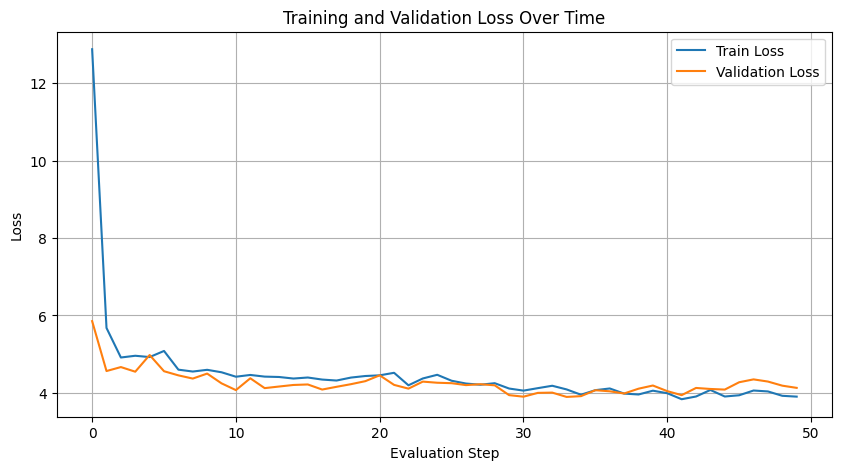

In [24]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))
plt.plot(train_losses, label="Train Loss")
plt.plot(val_losses, label="Validation Loss")
plt.xlabel("Evaluation Step")
plt.ylabel("Loss")
plt.title("Training and Validation Loss Over Time")
plt.legend()
plt.grid()
plt.show()

In [32]:
from utils import load_from_checkpoint
from models import generate

model = load_from_checkpoint(
    "/home/GPT/Train_Your_Language_Model_Course/output/checkpoints/checkpoint_49.pth",
    model=model,
    device=device)

def get_input_tokens(message: str) -> torch.Tensor:
    input_tokens = tokenizer.encode(
        f"<|startoftext|>{message}<|separator|>", allowed_special="all")
    input_tokens = torch.tensor(
        input_tokens, dtype=torch.long).unsqueeze(0).to(device)
    return input_tokens


user_message = "When will you leave?"
input_tokens = get_input_tokens(message=user_message)
model_answer = ""

model.eval()
while True:
    output_tokens = generate(model, block_size, input_tokens=input_tokens, max_new_tokens=1)
    last_generated_token = output_tokens[0, -1].item()
    if last_generated_token == tokenizer._special_tokens["<|endoftext|>"]:
        break

    input_tokens = torch.cat((input_tokens, output_tokens[:, -1:]), dim=1)
    model_answer += tokenizer.decode([last_generated_token])

    if len(output_tokens[0]) > block_size:
        input_tokens = input_tokens[:, -block_size:]

print(f"You: {user_message}")
print(f"Assistant: {model_answer}")

You: When will you leave?
Assistant: You carry mart
